In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
movie = pd.read_csv(r"C:\Users\Jatin Sudam Patil\Downloads\archive M\movies.csv")
rating= pd.read_csv(r"C:\Users\Jatin Sudam Patil\Downloads\archive M\ratings.csv")

In [3]:
movie.info()
rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


In [6]:
data = pd.merge(rating, movie, on="movieId")

print(data.head())

   userId  movieId  rating   timestamp  \
0       1      296     5.0  1147880044   
1       1      306     3.5  1147868817   
2       1      307     5.0  1147868828   
3       1      665     5.0  1147878820   
4       1      899     3.5  1147868510   

                                              title  \
0                               Pulp Fiction (1994)   
1  Three Colors: Red (Trois couleurs: Rouge) (1994)   
2  Three Colors: Blue (Trois couleurs: Bleu) (1993)   
3                                Underground (1995)   
4                        Singin' in the Rain (1952)   

                        genres  
0  Comedy|Crime|Drama|Thriller  
1                        Drama  
2                        Drama  
3             Comedy|Drama|War  
4       Comedy|Musical|Romance  


In [7]:
data = data.sample(20000)

In [8]:
top_movies = data.groupby("title")["rating"].mean().sort_values(ascending=False)

print(top_movies.head(10))

title
'71 (2014)                                           5.0
Big Kahuna, The (2000)                               5.0
One Magic Christmas (1985)                           5.0
Out of the Past (1947)                               5.0
Outsiders, The (1983)                                5.0
Paddington (2014)                                    5.0
Pajama Game, The (1957)                              5.0
Palm Beach Story, The (1942)                         5.0
Blue Is the Warmest Color (La vie d'Adèle) (2013)    5.0
Blue Angel, The (Blaue Engel, Der) (1930)            5.0
Name: rating, dtype: float64


In [9]:
ratings_count = data.groupby("title")["rating"].count()

ratings_mean = data.groupby("title")["rating"].mean()

ratings_df = pd.DataFrame({
    "average_rating": ratings_mean,
    "rating_count": ratings_count
})

print(ratings_df.head())

                                         average_rating  rating_count
title                                                                
'71 (2014)                                        5.000             1
'Twas the Night Before Christmas (1974)           0.500             1
'burbs, The (1989)                                3.625             4
(500) Days of Summer (2009)                       2.875             4
1-900 (06) (1994)                                 3.000             1


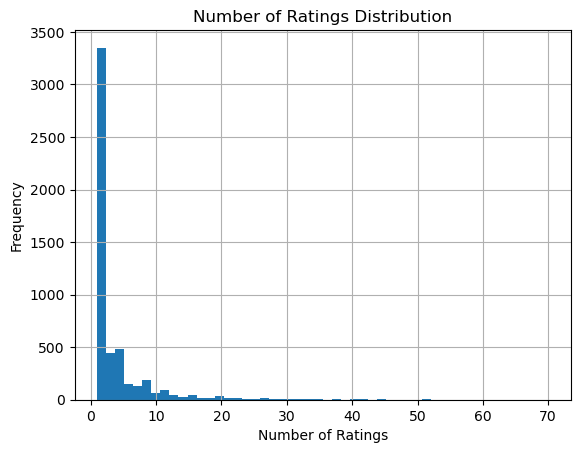

In [10]:
plt.figure()

ratings_df["rating_count"].hist(bins=50)

plt.title("Number of Ratings Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Frequency")

plt.show()

In [11]:
movie_matrix = data.pivot_table(index="userId", columns="title", values="rating")

print(movie_matrix.head())

title   '71 (2014)  'Twas the Night Before Christmas (1974)  \
userId                                                        
19             NaN                                      NaN   
26             NaN                                      NaN   
57             NaN                                      NaN   
60             NaN                                      NaN   
61             NaN                                      NaN   

title   'burbs, The (1989)  (500) Days of Summer (2009)  1-900 (06) (1994)  \
userId                                                                       
19                     NaN                          NaN                NaN   
26                     NaN                          NaN                NaN   
57                     NaN                          NaN                NaN   
60                     NaN                          NaN                NaN   
61                     NaN                          NaN                NaN   

title   10 

In [12]:
toy_story = movie_matrix["Toy Story (1995)"]

similar_movies = movie_matrix.corrwith(toy_story)

corr_movies = pd.DataFrame(similar_movies, columns=["Correlation"])

corr_movies.dropna(inplace=True)

print(corr_movies.sort_values("Correlation", ascending=False).head(10))

C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


                  Correlation
title                        
Toy Story (1995)          1.0


In [13]:
def recommend(movie_name):

    movie_rating = movie_matrix[movie_name]

    similar = movie_matrix.corrwith(movie_rating)

    corr_df = pd.DataFrame(similar, columns=["Correlation"])

    corr_df.dropna(inplace=True)

    return corr_df.sort_values("Correlation", ascending=False).head(10)

In [14]:
print(recommend("Toy Story (1995)"))

C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


                  Correlation
title                        
Toy Story (1995)          1.0
